# S&P 500 Volatility Regime Forecasting with XAI

This notebook trains neural networks to forecast whether the S&P 500 will enter a high-volatility regime over the next five trading days.

The project compares three sequence models and applies multiple explanation methods:

- LSTM
- 1D CNN
- Transformer Encoder
- Concept-level Shapley attribution
- WindowSHAP
- Integrated Gradients
- Official decomposition-based C-SHAP for a univariate volatility model

The main target is binary:

```text
1 = high-volatility regime
0 = normal/low-volatility regime
```

High volatility is defined using the 70th percentile of future realized volatility in the training set.


## 1. Setup

In [1]:
# Run once if needed:
# !pip install numpy pandas yfinance scikit-learn torch captum matplotlib shap PyWavelets emd

In [2]:
import sys
import random
import warnings
from dataclasses import dataclass
from pathlib import Path

import numpy as np
import pandas as pd
import yfinance as yf

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
)

from captum.attr import IntegratedGradients

import matplotlib.pyplot as plt
from matplotlib.collections import LineCollection
from matplotlib.colors import Normalize

warnings.filterwarnings("ignore")

In [3]:
@dataclass
class Config:
    ticker: str = "^GSPC"
    start_date: str = "2000-01-01"
    end_date: str | None = None

    lookback: int = 30
    forecast_horizon: int = 5
    high_vol_quantile: float = 0.70

    batch_size: int = 64
    epochs: int = 30
    patience: int = 5
    learning_rate: float = 1e-3

    train_ratio: float = 0.70
    val_ratio: float = 0.15

    seed: int = 42

    shap_samples: int = 300
    window_size: int = 5

    cshap_background: int = 20
    cshap_explain: int = 40
    cshap_exact: bool = True

    output_dir: str = "outputs"


cfg = Config()

FEATURES = [
    "log_return",
    "abs_return",
    "squared_return",
    "high_low_range",
    "open_close_range",
    "volume_change",
    "sma_5_gap",
    "sma_20_gap",
    "volatility_5",
    "volatility_20",
    "rsi_14",
]

UNIVARIATE_FEATURES = ["abs_return"]

def set_seed(seed: int) -> None:
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

set_seed(cfg.seed)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
output_dir = Path(cfg.output_dir)
output_dir.mkdir(exist_ok=True)

device

device(type='cuda')

## 2. Official C-SHAP import

The official C-SHAP repository should either be the current working directory or available as `CSHAP-for-time-series.zip`.


In [4]:
def dataset_to_numpy(dataset: Dataset, n_samples: int | None = None, start_idx: int = 0):
    if n_samples is None:
        n_samples = len(dataset) - start_idx

    x_values = []
    y_values = []

    end_idx = min(start_idx + n_samples, len(dataset))
    for idx in range(start_idx, end_idx):
        x, y = dataset[idx]
        x_values.append(x.numpy())
        y_values.append(y.item())

    return np.stack(x_values), np.array(y_values)


In [5]:
def load_cshap():
    root = Path.cwd()

    if (root / "scripts" / "cshap").exists():
        sys.path.insert(0, str(root))
        from scripts.cshap import CSHAP, CustomDecomposition
        return CSHAP, CustomDecomposition

    zip_candidates = [
        root / "CSHAP-for-time-series.zip",
        Path("/mnt/data/CSHAP-for-time-series.zip"),
    ]

    zip_path = next((p for p in zip_candidates if p.exists()), None)
    if zip_path is None:
        raise FileNotFoundError(
            "C-SHAP code not found. Run this notebook inside the extracted repository "
            "or place CSHAP-for-time-series.zip next to the notebook."
        )

    import zipfile

    extract_dir = root / "CSHAP_for_time_series_extracted"
    extract_dir.mkdir(exist_ok=True)

    with zipfile.ZipFile(zip_path, "r") as zf:
        zf.extractall(extract_dir)

    repo_root = extract_dir / "CSHAP-for-time-series"
    if not (repo_root / "scripts" / "cshap").exists():
        matches = list(extract_dir.glob("**/scripts/cshap"))
        if not matches:
            raise FileNotFoundError("Could not locate scripts/cshap in the extracted files.")
        repo_root = matches[0].parents[1]

    sys.path.insert(0, str(repo_root))
    from scripts.cshap import CSHAP, CustomDecomposition
    return CSHAP, CustomDecomposition


CSHAP, CustomDecomposition = load_cshap()

## 3. Data preparation

In [6]:
def compute_rsi(series: pd.Series, period: int = 14) -> pd.Series:
    delta = series.diff()
    gain = delta.clip(lower=0)
    loss = -delta.clip(upper=0)

    avg_gain = gain.rolling(period).mean()
    avg_loss = loss.rolling(period).mean()

    rs = avg_gain / (avg_loss + 1e-8)
    return 100 - (100 / (1 + rs))


def future_rolling_std(series: pd.Series, horizon: int) -> pd.Series:
    return (
        series
        .shift(-1)
        .rolling(window=horizon)
        .std()
        .shift(-(horizon - 1))
    )


def load_market_data(config: Config) -> pd.DataFrame:
    df = yf.download(
        config.ticker,
        start=config.start_date,
        end=config.end_date,
        auto_adjust=True,
        progress=False,
    )

    if df.empty:
        raise ValueError("No data downloaded.")

    if isinstance(df.columns, pd.MultiIndex):
        df.columns = [col[0] for col in df.columns]

    df = df[["Open", "High", "Low", "Close", "Volume"]].copy()

    for col in df.columns:
        df[col] = pd.to_numeric(df[col], errors="coerce")

    df["Volume"] = df["Volume"].replace(0, np.nan)

    df["log_return"] = np.log(df["Close"] / df["Close"].shift(1))
    df["abs_return"] = df["log_return"].abs()
    df["squared_return"] = df["log_return"] ** 2

    df["high_low_range"] = (df["High"] - df["Low"]) / df["Close"]
    df["open_close_range"] = (df["Close"] - df["Open"]) / df["Open"]
    df["volume_change"] = np.log(df["Volume"] / df["Volume"].shift(1))

    df["sma_5_gap"] = df["Close"] / df["Close"].rolling(5).mean() - 1
    df["sma_20_gap"] = df["Close"] / df["Close"].rolling(20).mean() - 1

    df["volatility_5"] = df["log_return"].rolling(5).std()
    df["volatility_20"] = df["log_return"].rolling(20).std()

    df["rsi_14"] = compute_rsi(df["Close"])
    df["future_realized_vol"] = future_rolling_std(
        df["log_return"],
        config.forecast_horizon,
    )

    return df.replace([np.inf, -np.inf], np.nan).dropna()


def add_target(df: pd.DataFrame, config: Config) -> tuple[pd.DataFrame, float]:
    train_end = int(len(df) * config.train_ratio)
    threshold = df.iloc[:train_end]["future_realized_vol"].quantile(
        config.high_vol_quantile
    )

    out = df.copy()
    out["target"] = (out["future_realized_vol"] > threshold).astype(int)
    return out, float(threshold)


df = load_market_data(cfg)
df, high_vol_threshold = add_target(df, cfg)

print(f"Rows: {len(df)}")
print(f"High-volatility threshold: {high_vol_threshold:.6f}")
df[["log_return", "volatility_20", "future_realized_vol", "target"]].head()

Rows: 6626
High-volatility threshold: 0.011019


,log_return,volatility_20,future_realized_vol,target
Date,,,,
2000-02-01,0.010572,0.016607,0.006529,0
2000-02-02,-0.000114,0.014069,0.013378,1
2000-02-03,0.011185,0.014274,0.012227,1
2000-02-04,-0.000421,0.014277,0.015108,1
2000-02-07,-0.000091,0.012900,0.015320,1


In [7]:
class SequenceDataset(Dataset):
    def __init__(self, x: np.ndarray, y: np.ndarray, lookback: int):
        self.x = x
        self.y = y
        self.lookback = lookback

    def __len__(self) -> int:
        return len(self.x) - self.lookback

    def __getitem__(self, idx: int):
        if idx < 0:
            idx = len(self) + idx

        x_seq = self.x[idx:idx + self.lookback]
        y_val = self.y[idx + self.lookback]

        return (
            torch.tensor(x_seq, dtype=torch.float32),
            torch.tensor(y_val, dtype=torch.float32),
        )


def make_datasets(df: pd.DataFrame, features: list[str], config: Config):
    n = len(df)
    train_end = int(n * config.train_ratio)
    val_end = int(n * (config.train_ratio + config.val_ratio))

    train_df = df.iloc[:train_end].copy()
    val_df = df.iloc[train_end:val_end].copy()
    test_df = df.iloc[val_end:].copy()

    scaler = StandardScaler()
    scaler.fit(train_df[features])

    x_train = scaler.transform(train_df[features])
    x_val = scaler.transform(val_df[features])
    x_test = scaler.transform(test_df[features])

    y_train = train_df["target"].values
    y_val = val_df["target"].values
    y_test = test_df["target"].values

    datasets = (
        SequenceDataset(x_train, y_train, config.lookback),
        SequenceDataset(x_val, y_val, config.lookback),
        SequenceDataset(x_test, y_test, config.lookback),
    )

    frames = (train_df, val_df, test_df)
    return datasets, scaler, frames


def make_loaders(datasets, config: Config):
    train_ds, val_ds, test_ds = datasets

    return (
        DataLoader(train_ds, batch_size=config.batch_size, shuffle=True),
        DataLoader(val_ds, batch_size=config.batch_size, shuffle=False),
        DataLoader(test_ds, batch_size=config.batch_size, shuffle=False),
    )


main_datasets, main_scaler, main_frames = make_datasets(df, FEATURES, cfg)
uni_datasets, uni_scaler, uni_frames = make_datasets(df, UNIVARIATE_FEATURES, cfg)

train_ds, val_ds, test_ds = main_datasets
train_loader, val_loader, test_loader = make_loaders(main_datasets, cfg)

train_ds_uni, val_ds_uni, test_ds_uni = uni_datasets
train_loader_uni, val_loader_uni, test_loader_uni = make_loaders(uni_datasets, cfg)

print(len(train_ds), len(val_ds), len(test_ds))
print(len(train_ds_uni), len(val_ds_uni), len(test_ds_uni))

4608 964 964
4608 964 964


## 4. Model definitions

In [8]:
class LSTMModel(nn.Module):
    def __init__(self, n_features: int, hidden_size: int = 64, num_layers: int = 2, dropout: float = 0.2):
        super().__init__()
        self.lstm = nn.LSTM(
            input_size=n_features,
            hidden_size=hidden_size,
            num_layers=num_layers,
            dropout=dropout,
            batch_first=True,
        )
        self.head = nn.Sequential(
            nn.Linear(hidden_size, 32),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(32, 1),
        )

    def forward(self, x):
        out, _ = self.lstm(x)
        return self.head(out[:, -1, :]).squeeze(-1)


class CNN1DModel(nn.Module):
    def __init__(self, n_features: int, hidden_channels: int = 64, dropout: float = 0.2):
        super().__init__()
        self.encoder = nn.Sequential(
            nn.Conv1d(n_features, hidden_channels, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.BatchNorm1d(hidden_channels),
            nn.Conv1d(hidden_channels, hidden_channels, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.BatchNorm1d(hidden_channels),
            nn.AdaptiveAvgPool1d(1),
        )
        self.head = nn.Sequential(
            nn.Flatten(),
            nn.Linear(hidden_channels, 32),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(32, 1),
        )

    def forward(self, x):
        x = x.transpose(1, 2)
        return self.head(self.encoder(x)).squeeze(-1)


class TransformerModel(nn.Module):
    def __init__(
        self,
        n_features: int,
        d_model: int = 64,
        nhead: int = 4,
        num_layers: int = 2,
        dropout: float = 0.2,
        max_len: int = 500,
    ):
        super().__init__()
        self.proj = nn.Linear(n_features, d_model)
        self.pos = nn.Parameter(torch.randn(1, max_len, d_model) * 0.01)

        layer = nn.TransformerEncoderLayer(
            d_model=d_model,
            nhead=nhead,
            dim_feedforward=128,
            dropout=dropout,
            batch_first=True,
            activation="gelu",
        )
        self.encoder = nn.TransformerEncoder(layer, num_layers=num_layers)
        self.head = nn.Sequential(
            nn.Linear(d_model, 32),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(32, 1),
        )

    def forward(self, x):
        seq_len = x.shape[1]
        x = self.proj(x) + self.pos[:, :seq_len, :]
        x = self.encoder(x)
        return self.head(x[:, -1, :]).squeeze(-1)


class ProbabilityModel(nn.Module):
    def __init__(self, model: nn.Module):
        super().__init__()
        self.model = model

    def forward(self, x):
        return torch.sigmoid(self.model(x))

## 5. Training and evaluation

In [9]:
def class_weight(loader: DataLoader) -> torch.Tensor:
    labels = []
    for _, y in loader:
        labels.extend(y.numpy())

    labels = np.array(labels).astype(int)
    positives = labels.sum()
    negatives = len(labels) - positives

    if positives == 0:
        return torch.tensor(1.0, dtype=torch.float32)

    return torch.tensor(negatives / positives, dtype=torch.float32)


def train_model(model: nn.Module, train_loader: DataLoader, val_loader: DataLoader, config: Config):
    model = model.to(device)

    pos_weight = class_weight(train_loader).to(device)
    loss_fn = nn.BCEWithLogitsLoss(pos_weight=pos_weight)
    optimizer = torch.optim.AdamW(model.parameters(), lr=config.learning_rate, weight_decay=1e-4)

    best_loss = np.inf
    best_state = None
    stale_epochs = 0

    for epoch in range(config.epochs):
        model.train()
        train_losses = []

        for x, y in train_loader:
            x = x.to(device)
            y = y.to(device)

            optimizer.zero_grad()
            loss = loss_fn(model(x), y)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            optimizer.step()

            train_losses.append(loss.item())

        model.eval()
        val_losses = []
        with torch.no_grad():
            for x, y in val_loader:
                x = x.to(device)
                y = y.to(device)
                val_losses.append(loss_fn(model(x), y).item())

        val_loss = float(np.mean(val_losses))
        print(f"Epoch {epoch + 1:02d} | train={np.mean(train_losses):.4f} | val={val_loss:.4f}")

        if val_loss < best_loss:
            best_loss = val_loss
            best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
            stale_epochs = 0
        else:
            stale_epochs += 1

        if stale_epochs >= config.patience:
            break

    if best_state is not None:
        model.load_state_dict(best_state)

    return model


def predict_proba(model: nn.Module, loader: DataLoader):
    model.eval()

    probs = []
    labels = []

    with torch.no_grad():
        for x, y in loader:
            x = x.to(device)
            probs.extend(torch.sigmoid(model(x)).cpu().numpy())
            labels.extend(y.numpy())

    return np.array(probs), np.array(labels).astype(int)


def tune_threshold(labels: np.ndarray, probs: np.ndarray) -> float:
    thresholds = np.linspace(0.05, 0.95, 181)
    scores = []

    for threshold in thresholds:
        preds = (probs >= threshold).astype(int)
        scores.append(balanced_accuracy_score(labels, preds))

    return float(thresholds[int(np.argmax(scores))])


def evaluate_model(model: nn.Module, loader: DataLoader, threshold: float):
    probs, labels = predict_proba(model, loader)
    preds = (probs >= threshold).astype(int)

    return {
        "threshold": threshold,
        "accuracy": accuracy_score(labels, preds),
        "balanced_accuracy": balanced_accuracy_score(labels, preds),
        "precision": precision_score(labels, preds, zero_division=0),
        "recall": recall_score(labels, preds, zero_division=0),
        "f1": f1_score(labels, preds, zero_division=0),
        "roc_auc": roc_auc_score(labels, probs),
        "confusion_matrix": confusion_matrix(labels, preds),
        "probs": probs,
        "labels": labels,
        "preds": preds,
    }

## 6. Plot helpers

In [10]:
def save_plot(path: str | Path | None = None):
    plt.tight_layout()
    if path is not None:
        plt.savefig(path, dpi=200, bbox_inches="tight")
    plt.show()


def plot_probability_series(labels, probs, title, path=None):
    plt.figure(figsize=(12, 4))
    plt.plot(labels, label="actual", alpha=0.8)
    plt.plot(probs, label="predicted probability", alpha=0.8)
    plt.axhline(0.5, linestyle="--", linewidth=1)
    plt.title(title)
    plt.xlabel("test sample")
    plt.ylabel("high-volatility class / probability")
    plt.legend()
    save_plot(path)


def plot_probability_histogram(labels, probs, title, path=None):
    labels = np.asarray(labels)
    probs = np.asarray(probs)

    plt.figure(figsize=(8, 4))
    plt.hist(probs[labels == 0], bins=30, alpha=0.6, label="normal/low volatility")
    plt.hist(probs[labels == 1], bins=30, alpha=0.6, label="high volatility")
    plt.axvline(0.5, linestyle="--", linewidth=1)
    plt.title(title)
    plt.xlabel("predicted probability")
    plt.ylabel("count")
    plt.legend()
    save_plot(path)


def plot_bar(values: dict[str, float], title: str, ylabel: str, path=None):
    names = np.array(list(values.keys()))
    vals = np.array(list(values.values()))
    order = np.argsort(np.abs(vals))[::-1]

    plt.figure(figsize=(9, 4))
    plt.bar(names[order], vals[order])
    plt.xticks(rotation=45, ha="right")
    plt.ylabel(ylabel)
    plt.title(title)
    save_plot(path)


def plot_heatmap(values, labels, title, path=None):
    plt.figure(figsize=(12, 5))
    plt.imshow(values.T, aspect="auto")
    plt.yticks(range(len(labels)), labels)
    plt.xlabel("time step")
    plt.ylabel("feature")
    plt.title(title)
    plt.colorbar(label="attribution")
    save_plot(path)

## 7. Train the main models


LSTM
Epoch 01 | train=0.7778 | val=0.7917
Epoch 02 | train=0.6555 | val=0.8868
Epoch 03 | train=0.6308 | val=0.7913
Epoch 04 | train=0.6196 | val=0.8144
Epoch 05 | train=0.6116 | val=0.7914
Epoch 06 | train=0.6062 | val=0.7906
Epoch 07 | train=0.6006 | val=0.7843
Epoch 08 | train=0.5911 | val=0.7868
Epoch 09 | train=0.5881 | val=0.8440
Epoch 10 | train=0.5845 | val=0.8314
Epoch 11 | train=0.5794 | val=0.8815
Epoch 12 | train=0.5731 | val=0.8239
threshold: 0.490
balanced accuracy: 0.717
[[622 123]
 [ 88 131]]


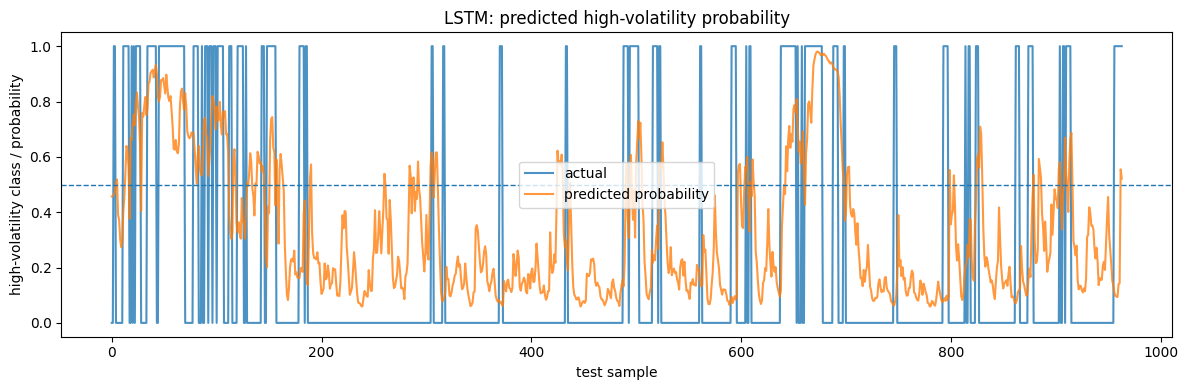

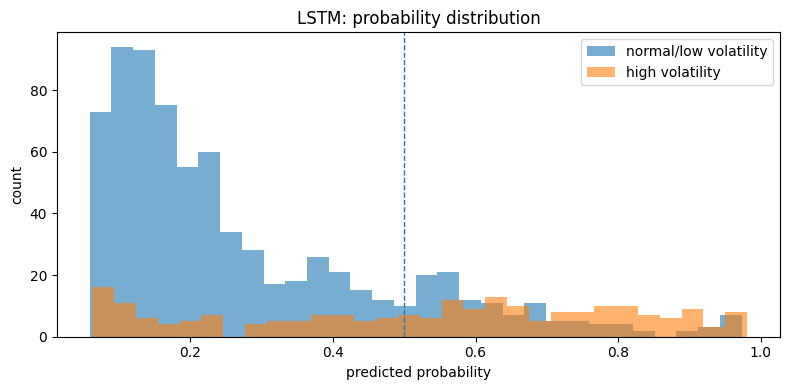


CNN
Epoch 01 | train=0.7245 | val=0.8751
Epoch 02 | train=0.6553 | val=0.7885
Epoch 03 | train=0.6241 | val=0.7990
Epoch 04 | train=0.6046 | val=0.7698
Epoch 05 | train=0.5821 | val=0.8073
Epoch 06 | train=0.5779 | val=0.8301
Epoch 07 | train=0.5568 | val=0.8965
Epoch 08 | train=0.5447 | val=0.9411
Epoch 09 | train=0.5154 | val=0.9384
threshold: 0.465
balanced accuracy: 0.696
[[629 116]
 [ 99 120]]


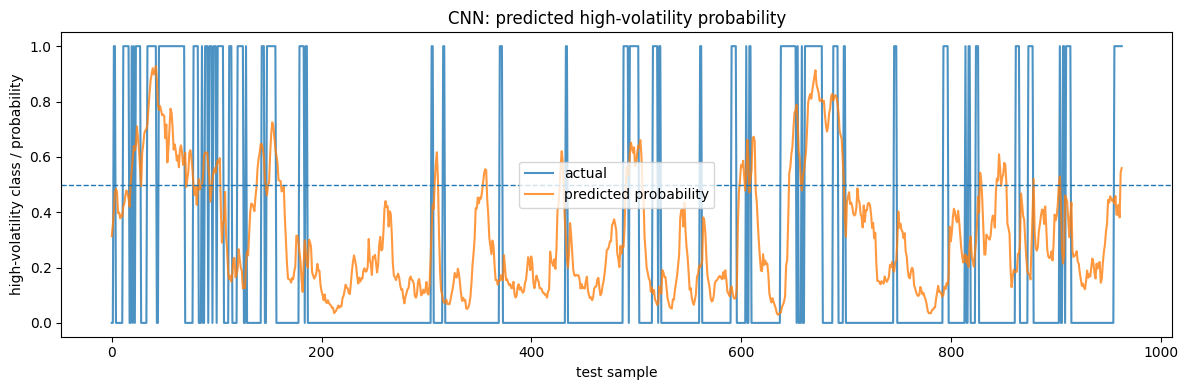

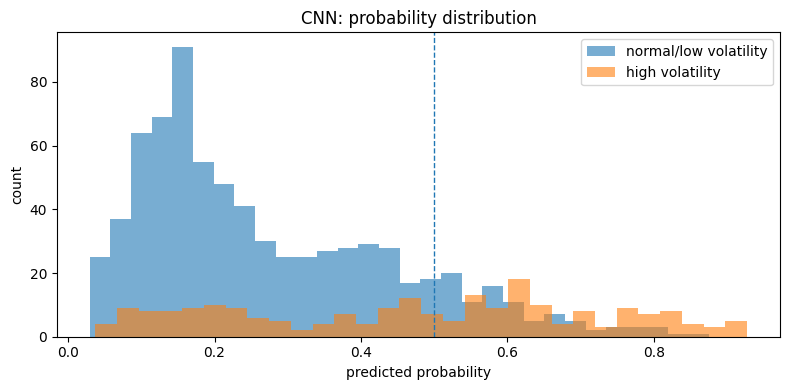


Transformer
Epoch 01 | train=0.7011 | val=0.8014
Epoch 02 | train=0.6422 | val=0.8182
Epoch 03 | train=0.6380 | val=0.7513
Epoch 04 | train=0.6159 | val=0.7999
Epoch 05 | train=0.6122 | val=0.8001
Epoch 06 | train=0.5912 | val=0.8304
Epoch 07 | train=0.5843 | val=0.8484
Epoch 08 | train=0.5773 | val=0.7625
threshold: 0.440
balanced accuracy: 0.720
[[563 182]
 [ 69 150]]


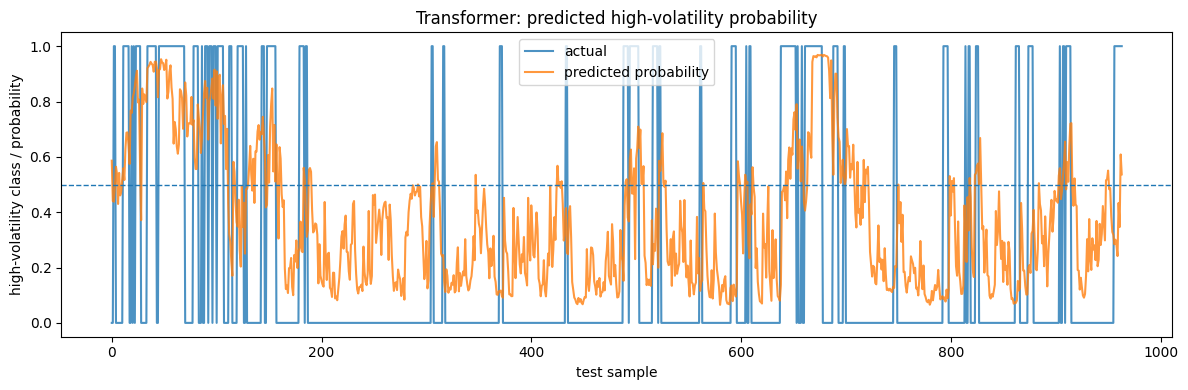

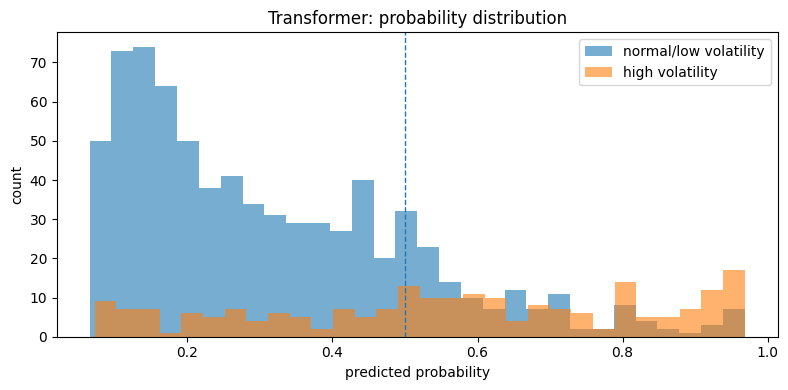

,model,threshold,accuracy,balanced_accuracy,precision,recall,f1,roc_auc
0,LSTM,0.490,0.781120,0.716536,0.515748,0.598174,0.553911,0.758506
1,CNN,0.465,0.776971,0.696120,0.508475,0.547945,0.527473,0.738653
2,Transformer,0.440,0.739627,0.720318,0.451807,0.684932,0.544465,0.768527


In [11]:
models = {
    "LSTM": LSTMModel(len(FEATURES)),
    "CNN": CNN1DModel(len(FEATURES)),
    "Transformer": TransformerModel(len(FEATURES)),
}

trained_models = {}
results = {}

for name, model in models.items():
    print(f"\n{name}")
    trained = train_model(model, train_loader, val_loader, cfg)
    trained_models[name] = trained

    val_probs, val_labels = predict_proba(trained, val_loader)
    threshold = tune_threshold(val_labels, val_probs)

    metrics = evaluate_model(trained, test_loader, threshold)
    results[name] = metrics

    print(f"threshold: {threshold:.3f}")
    print(f"balanced accuracy: {metrics['balanced_accuracy']:.3f}")
    print(metrics["confusion_matrix"])

    plot_probability_series(
        metrics["labels"],
        metrics["probs"],
        f"{name}: predicted high-volatility probability",
        output_dir / f"{name}_probability_series.png",
    )

    plot_probability_histogram(
        metrics["labels"],
        metrics["probs"],
        f"{name}: probability distribution",
        output_dir / f"{name}_probability_histogram.png",
    )

summary = pd.DataFrame([
    {
        "model": name,
        "threshold": m["threshold"],
        "accuracy": m["accuracy"],
        "balanced_accuracy": m["balanced_accuracy"],
        "precision": m["precision"],
        "recall": m["recall"],
        "f1": m["f1"],
        "roc_auc": m["roc_auc"],
    }
    for name, m in results.items()
])

summary.to_csv(output_dir / "model_results.csv", index=False)
summary

## 8. Multivariate explanations

In [12]:
def financial_concepts(x: torch.Tensor, feature_names: list[str]):
    index = {name: i for i, name in enumerate(feature_names)}
    groups = {
        "returns": ["log_return", "abs_return", "squared_return"],
        "volatility": ["volatility_5", "volatility_20", "high_low_range"],
        "price_range": ["high_low_range", "open_close_range"],
        "momentum": ["sma_5_gap", "sma_20_gap", "rsi_14"],
        "volume": ["volume_change"],
    }

    concepts = {}
    for concept, cols in groups.items():
        tensor = torch.zeros_like(x)
        for col in cols:
            if col in index:
                tensor[:, :, index[col]] = x[:, :, index[col]]
        concepts[concept] = tensor

    return concepts


def concept_shap(model: nn.Module, x: torch.Tensor, baseline: torch.Tensor, concepts: dict[str, torch.Tensor], n_samples: int):
    model.eval()
    x = x.to(device)
    baseline = baseline.to(device)

    names = list(concepts.keys())
    values = {name: 0.0 for name in names}

    with torch.no_grad():
        for _ in range(n_samples):
            order = np.random.permutation(len(names))
            current = baseline.clone()
            previous = model(current).item()
            active = torch.zeros_like(x).to(device)

            for idx in order:
                name = names[idx]
                active = active + concepts[name].to(device)
                current = baseline + active

                new = model(current).item()
                values[name] += new - previous
                previous = new

    return {name: val / n_samples for name, val in values.items()}


def window_shap(model: nn.Module, x: torch.Tensor, baseline: torch.Tensor, window_size: int, n_samples: int):
    model.eval()
    x = x.to(device)
    baseline = baseline.to(device)

    lookback = x.shape[1]
    windows = [(i, min(i + window_size, lookback)) for i in range(0, lookback, window_size)]
    values = np.zeros(len(windows))

    with torch.no_grad():
        for _ in range(n_samples):
            order = np.random.permutation(len(windows))
            current = baseline.clone()
            previous = model(current).item()

            for idx in order:
                start, end = windows[idx]
                current[:, start:end, :] = x[:, start:end, :]

                new = model(current).item()
                values[idx] += new - previous
                previous = new

    return windows, values / n_samples


def integrated_gradients(model: nn.Module, x: torch.Tensor, baseline: torch.Tensor):
    was_training = model.training

    model = model.to(device)
    model.train()

    x = x.to(device)
    baseline = baseline.to(device)

    ig = IntegratedGradients(model)

    with torch.backends.cudnn.flags(enabled=False):
        attr, delta = ig.attribute(x, baselines=baseline, return_convergence_delta=True)

    if not was_training:
        model.eval()

    return attr.squeeze(0).detach().cpu().numpy(), float(delta.item())

selected model: Transformer
selected sample: 677
actual: 1
probability: 0.9685102105140686


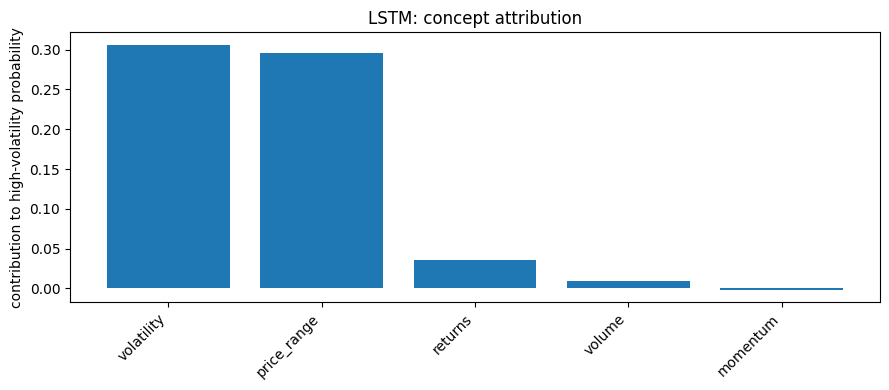

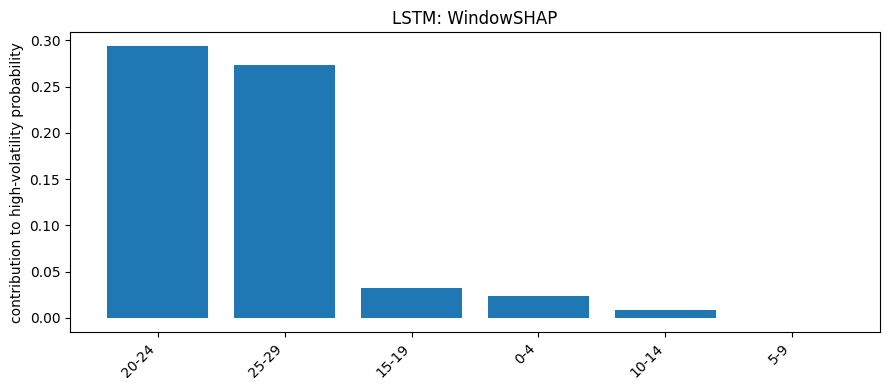

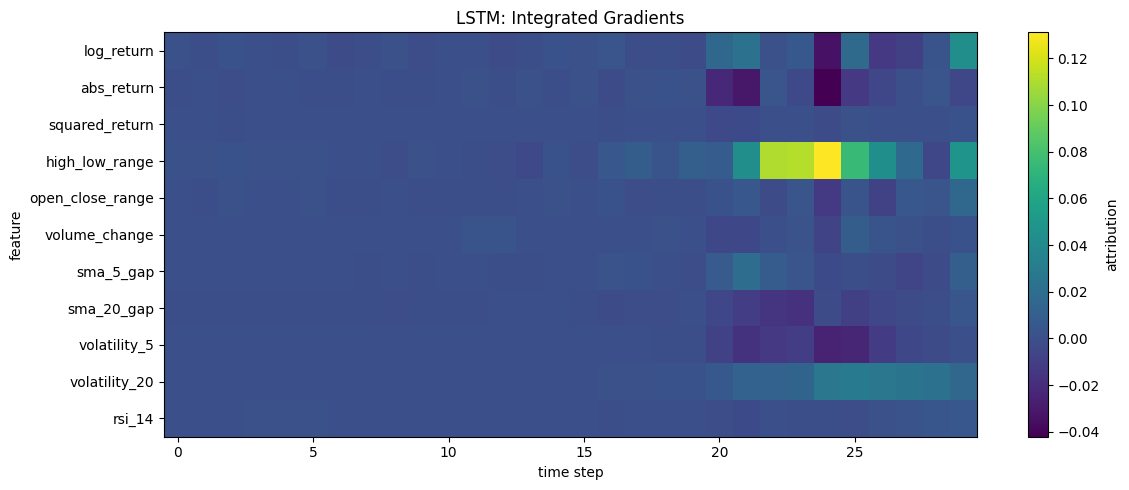

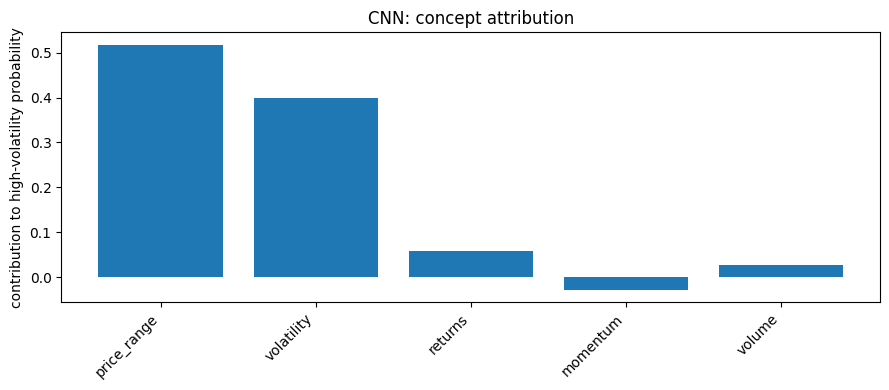

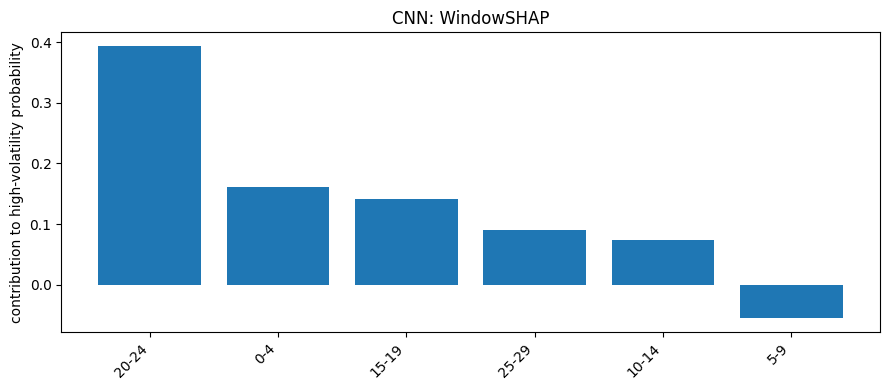

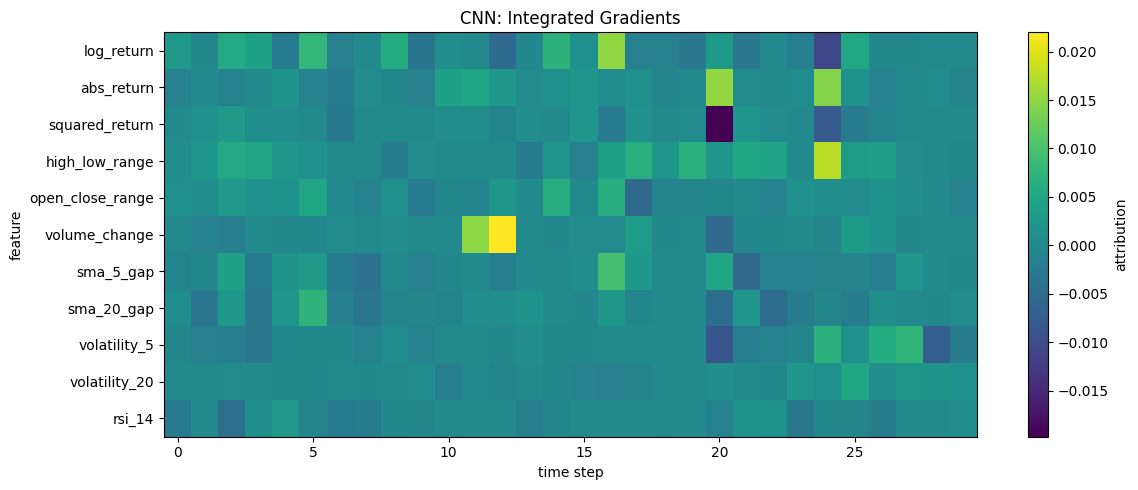

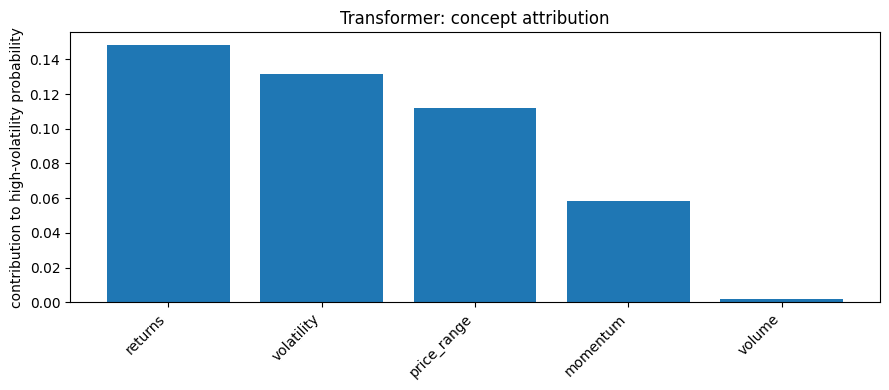

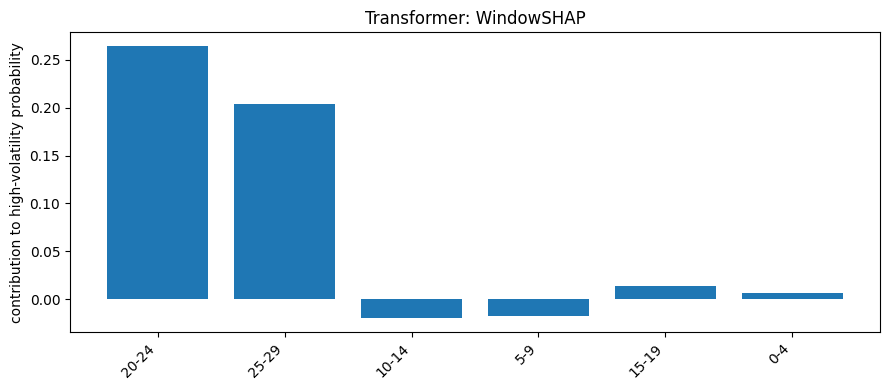

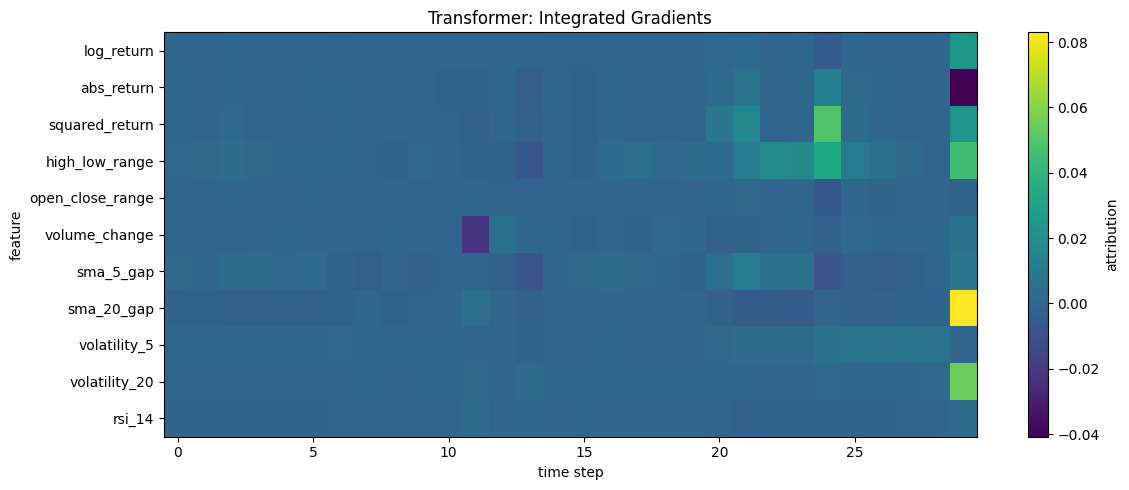

In [13]:
best_model_name = summary.sort_values("balanced_accuracy", ascending=False).iloc[0]["model"]
best_model = trained_models[best_model_name]

test_probs, _ = predict_proba(best_model, test_loader)
sample_idx = int(np.argmax(np.abs(test_probs - 0.5)))

x_instance, y_instance = test_ds[sample_idx]
x_instance = x_instance.unsqueeze(0)
baseline = torch.zeros_like(x_instance)

print("selected model:", best_model_name)
print("selected sample:", sample_idx)
print("actual:", int(y_instance.item()))
print("probability:", float(test_probs[sample_idx]))

for name, model in trained_models.items():
    prob_model = ProbabilityModel(model).to(device)

    concept_values = concept_shap(
        prob_model,
        x_instance,
        baseline,
        financial_concepts(x_instance, FEATURES),
        cfg.shap_samples,
    )

    pd.DataFrame({
        "concept": list(concept_values.keys()),
        "attribution": list(concept_values.values()),
    }).to_csv(output_dir / f"{name}_concept_shap.csv", index=False)

    plot_bar(
        concept_values,
        f"{name}: concept attribution",
        "contribution to high-volatility probability",
        output_dir / f"{name}_concept_shap.png",
    )

    windows, win_values = window_shap(
        prob_model,
        x_instance,
        baseline,
        cfg.window_size,
        cfg.shap_samples,
    )

    pd.DataFrame({
        "window": [f"{start}-{end - 1}" for start, end in windows],
        "attribution": win_values,
    }).to_csv(output_dir / f"{name}_window_shap.csv", index=False)

    plot_bar(
        {f"{start}-{end - 1}": val for (start, end), val in zip(windows, win_values)},
        f"{name}: WindowSHAP",
        "contribution to high-volatility probability",
        output_dir / f"{name}_window_shap.png",
    )

    ig_values, delta = integrated_gradients(prob_model, x_instance, baseline)
    pd.DataFrame(ig_values, columns=FEATURES).to_csv(output_dir / f"{name}_integrated_gradients.csv", index=False)

    plot_heatmap(
        ig_values,
        FEATURES,
        f"{name}: Integrated Gradients",
        output_dir / f"{name}_integrated_gradients.png",
    )

## 9. Univariate volatility model for official C-SHAP

Epoch 01 | train=0.8334 | val=0.8771
Epoch 02 | train=0.7149 | val=0.8189
Epoch 03 | train=0.7098 | val=0.8184
Epoch 04 | train=0.6967 | val=0.8461
Epoch 05 | train=0.6928 | val=0.8548
Epoch 06 | train=0.6878 | val=0.8002
Epoch 07 | train=0.6868 | val=0.8560
Epoch 08 | train=0.6886 | val=0.8409
Epoch 09 | train=0.6841 | val=0.8234
Epoch 10 | train=0.6852 | val=0.8121
Epoch 11 | train=0.6861 | val=0.9021
threshold: 0.585
balanced accuracy: 0.691
[[621 124]
 [ 99 120]]


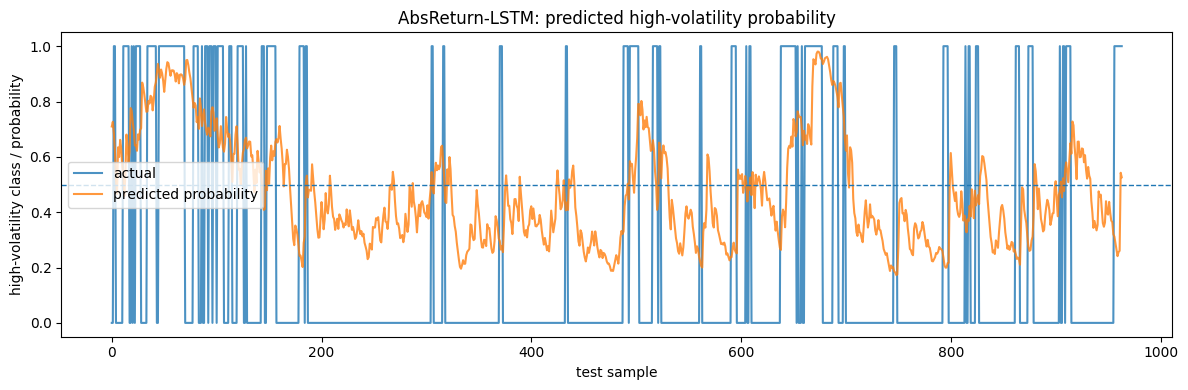

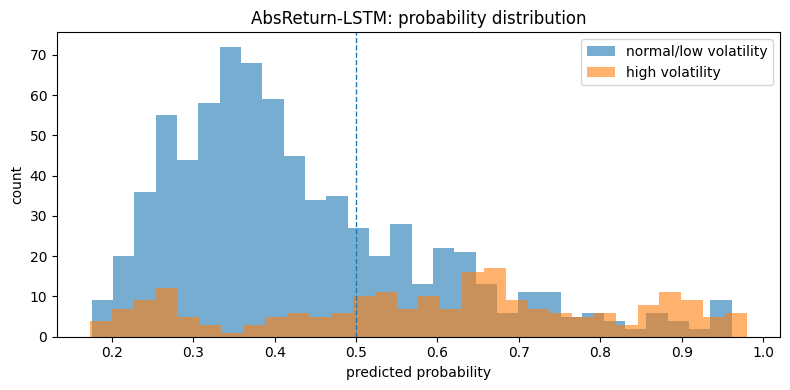

In [14]:
cshap_lstm = LSTMModel(n_features=1)

cshap_lstm = train_model(
    cshap_lstm,
    train_loader_uni,
    val_loader_uni,
    cfg,
)

val_probs_uni, val_labels_uni = predict_proba(cshap_lstm, val_loader_uni)
threshold_cshap = tune_threshold(val_labels_uni, val_probs_uni)

cshap_metrics = evaluate_model(cshap_lstm, test_loader_uni, threshold_cshap)

print(f"threshold: {threshold_cshap:.3f}")
print(f"balanced accuracy: {cshap_metrics['balanced_accuracy']:.3f}")
print(cshap_metrics["confusion_matrix"])

plot_probability_series(
    cshap_metrics["labels"],
    cshap_metrics["probs"],
    "AbsReturn-LSTM: predicted high-volatility probability",
    output_dir / "AbsReturn_LSTM_probability_series.png",
)

plot_probability_histogram(
    cshap_metrics["labels"],
    cshap_metrics["probs"],
    "AbsReturn-LSTM: probability distribution",
    output_dir / "AbsReturn_LSTM_probability_histogram.png",
)

In [ ]:
val_preds_uni = (val_probs_uni >= threshold_cshap).astype(int)

val_metrics_uni = {
    "precision": precision_score(val_labels_uni, val_preds_uni, zero_division=0),
    "recall": recall_score(val_labels_uni, val_preds_uni, zero_division=0),
    "f1": f1_score(val_labels_uni, val_preds_uni, zero_division=0),
    "auc": roc_auc_score(val_labels_uni, val_probs_uni),
}

print(pd.Series(val_metrics_uni))

## 10. Official C-SHAP

In [15]:
background_uni, _ = dataset_to_numpy(train_ds_uni, cfg.cshap_background)
x_cshap, y_cshap = dataset_to_numpy(test_ds_uni, cfg.cshap_explain)

t_cshap = np.linspace(0, cfg.lookback + 1, cfg.lookback)
decomposition = CustomDecomposition(
    "trend+bias+scale*(low_freq+var*high_freq)",
    noise_sigma=1,
    var_window_size=5,
)

# Official C-SHAP is applied to the raw model logit, not the sigmoid probability.
# Positive values increase evidence for a high-volatility regime.
# Negative values decrease evidence for a high-volatility regime.
cshap_logit_model = cshap_lstm.to(device)
cshap_logit_model.eval()

cshap = CSHAP(
    t=t_cshap,
    background_data=background_uni,
    decomposition=decomposition,
    softmax=False,
)

cshap_values, cshap_base_values = cshap.shap_values(
    t=t_cshap,
    x_samples=x_cshap,
    model=cshap_logit_model,
    device=device,
    exact=cfg.cshap_exact,
)

mean_values = cshap_values.mean(axis=0).squeeze()
mean_abs_values = np.abs(cshap_values).mean(axis=0).squeeze()

cshap_summary = pd.DataFrame({
    "component": decomposition.component_names,
    "mean_cshap_logit_value": mean_values,
    "mean_abs_cshap_logit_value": mean_abs_values,
}).sort_values("mean_abs_cshap_logit_value", ascending=False)

cshap_summary.to_csv(output_dir / "AbsReturn_LSTM_official_cshap_logit_summary.csv", index=False)
cshap_summary

,component,mean_cshap_logit_value,mean_abs_cshap_logit_value
1,bias,-0.755477,0.784286
0,trend,-0.137075,0.775839
3,low_freq,0.115573,0.167440
5,high_freq,0.002636,0.051220
2,scale,0.013547,0.029579
4,var,0.001597,0.014043


### Global C-SHAP importance

This plot summarizes the average absolute contribution of each decomposition component across the explained test samples. Since C-SHAP is applied to the raw logit, larger values mean a stronger average influence on the model's evidence for a high-volatility regime.


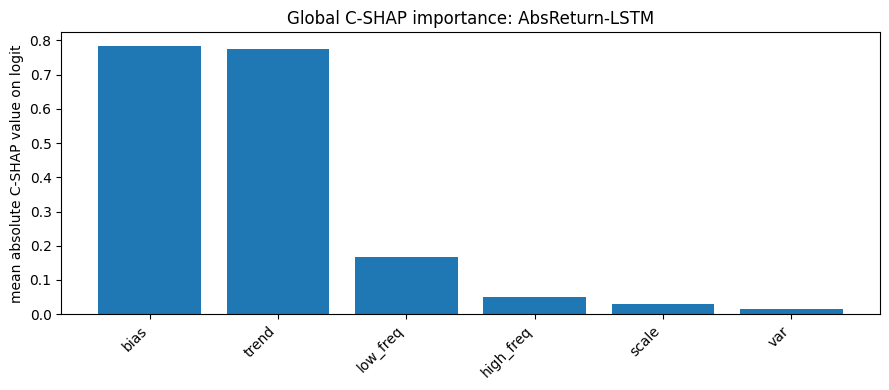

In [16]:
plot_bar(
    dict(zip(cshap_summary["component"], cshap_summary["mean_abs_cshap_logit_value"])),
    "Global C-SHAP importance: AbsReturn-LSTM",
    "mean absolute C-SHAP value on logit",
    output_dir / "AbsReturn_LSTM_global_cshap_logit_importance.png",
)

## 11. Instance-level C-SHAP visualization

In [17]:
def colored_line(ax, x, y, values, cmap="coolwarm"):
    points = np.array([x, y]).T.reshape(-1, 1, 2)
    segments = np.concatenate([points[:-1], points[1:]], axis=1)

    bound = np.max(np.abs(values)) + 1e-12
    norm = Normalize(vmin=-bound, vmax=bound)

    line = LineCollection(segments, cmap=cmap, norm=norm)
    line.set_array(values[:-1])
    line.set_linewidth(2)

    ax.add_collection(line)
    ax.scatter(x, y, c=values, cmap=cmap, norm=norm, s=18, zorder=3)
    ax.set_xlim(x.min(), x.max())

    y_range = np.ptp(y) or 1.0
    ax.set_ylim(y.min() - 0.1 * y_range, y.max() + 0.1 * y_range)

    return line


def distribute_cshap_over_time(components, shap_values):
    components = np.asarray(components)
    shap_values = np.asarray(shap_values).reshape(-1)

    n_time, n_components = components.shape
    attribution = np.zeros(n_time)

    for j in range(n_components):
        weights = np.abs(components[:, j])
        weights = weights / (weights.sum() + 1e-12)
        attribution += shap_values[j] * weights * n_time

    return attribution


def plot_cshap_instance(signal, decomposition, shap_values, base_logit, prediction_logit, prediction_prob, t, title, path=None):
    signal = np.asarray(signal).reshape(-1)
    shap_values = np.asarray(shap_values).squeeze()

    components = decomposition.decompose(t, signal.reshape(1, -1, 1))[0]
    time_attr = distribute_cshap_over_time(components, shap_values)

    fig = plt.figure(figsize=(16, 8))
    grid = fig.add_gridspec(
        nrows=7,
        ncols=3,
        width_ratios=[1.25, 0.55, 1.0],
        wspace=0.35,
        hspace=0.15,
    )

    fig.suptitle(title, fontsize=22)

    x_axis = np.arange(len(signal))

    ax_signal = fig.add_subplot(grid[2:5, 0])
    line = colored_line(ax_signal, x_axis, signal, time_attr)
    ax_signal.set_title("C-SHAP explanation")
    ax_signal.set_xlabel("time step")
    ax_signal.set_ylabel("standardized abs_return")
    fig.colorbar(line, ax=ax_signal, fraction=0.046, pad=0.04).set_label("visualized logit attribution")

    ax_original = fig.add_subplot(grid[0, 2])
    ax_original.plot(x_axis, signal)
    ax_original.set_title("signal decomposition")
    ax_original.set_xticks([])
    ax_original.yaxis.tick_right()

    limit = np.max(np.abs(shap_values)) + 1e-12

    for i, name in enumerate(decomposition.component_names):
        row = i + 1
        val = float(shap_values[i])

        ax_bar = fig.add_subplot(grid[row, 1])
        ax_bar.barh([0], [val], color="tab:red" if val >= 0 else "tab:blue")
        ax_bar.axvline(0, color="black", linewidth=0.8)
        ax_bar.set_xlim(-1.25 * limit, 1.25 * limit)
        ax_bar.set_yticks([])
        ax_bar.set_xticks([])
        ax_bar.set_ylabel(name, rotation=90, labelpad=18)
        ax_bar.text(
            val + np.sign(val if val != 0 else 1) * limit * 0.07,
            0,
            f"{val:+.6f}",
            va="center",
            ha="left" if val >= 0 else "right",
            fontsize=9,
        )

        ax_component = fig.add_subplot(grid[row, 2])
        ax_component.plot(x_axis, components[:, i])
        ax_component.set_xticks([])
        ax_component.yaxis.tick_right()

        if i == len(decomposition.component_names) - 1:
            ax_component.set_xlabel("time step")
            ax_component.set_xticks(np.linspace(0, len(signal) - 1, 5, dtype=int))

    fig.text(
        0.52,
        0.80,
        f"base logit\n= {float(np.asarray(base_logit).squeeze()):.3f}",
        ha="center",
        va="center",
        fontsize=12,
    )
    fig.text(
        0.52,
        0.12,
        f"prediction logit\n= {prediction_logit:.3f}\nP(high vol) = {prediction_prob:.3f}",
        ha="center",
        va="center",
        fontsize=12,
    )

    if path is not None:
        plt.savefig(path, dpi=200, bbox_inches="tight")

    plt.show()
    return fig

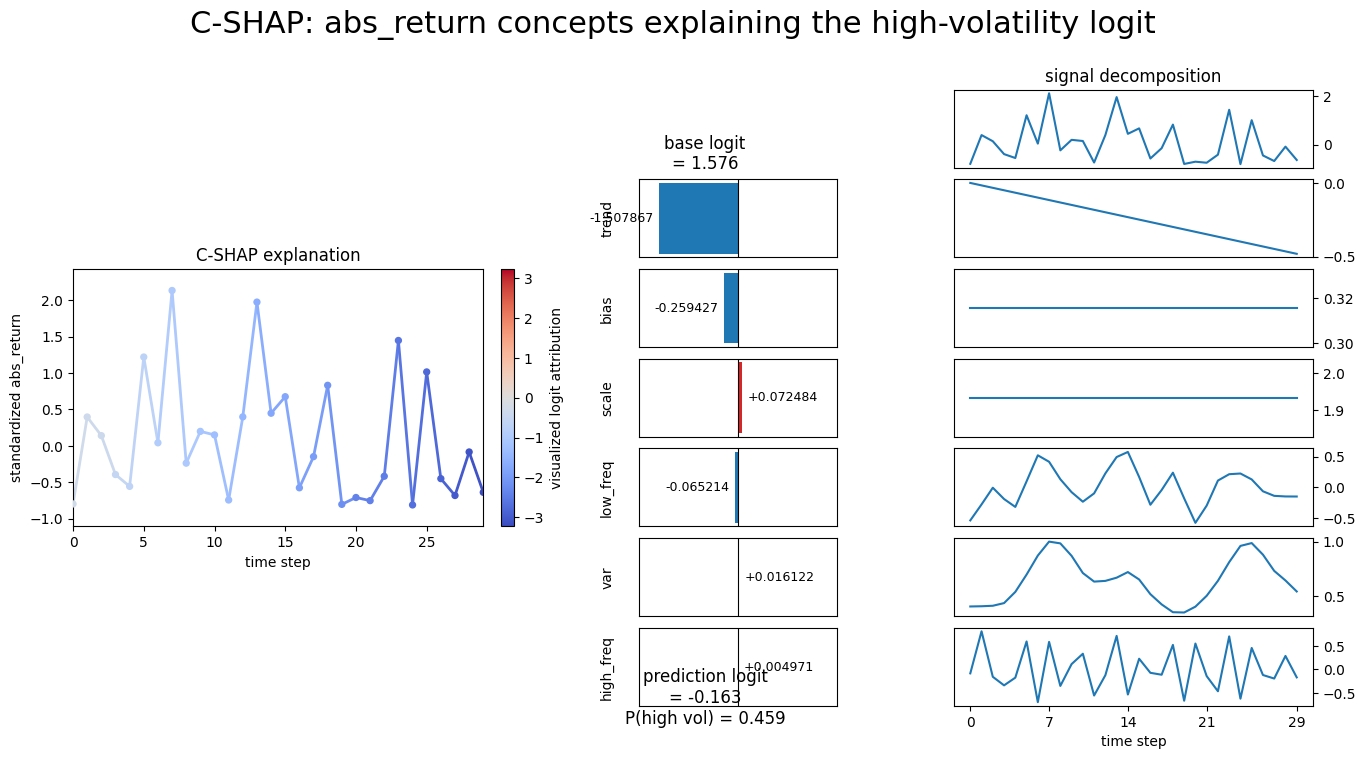

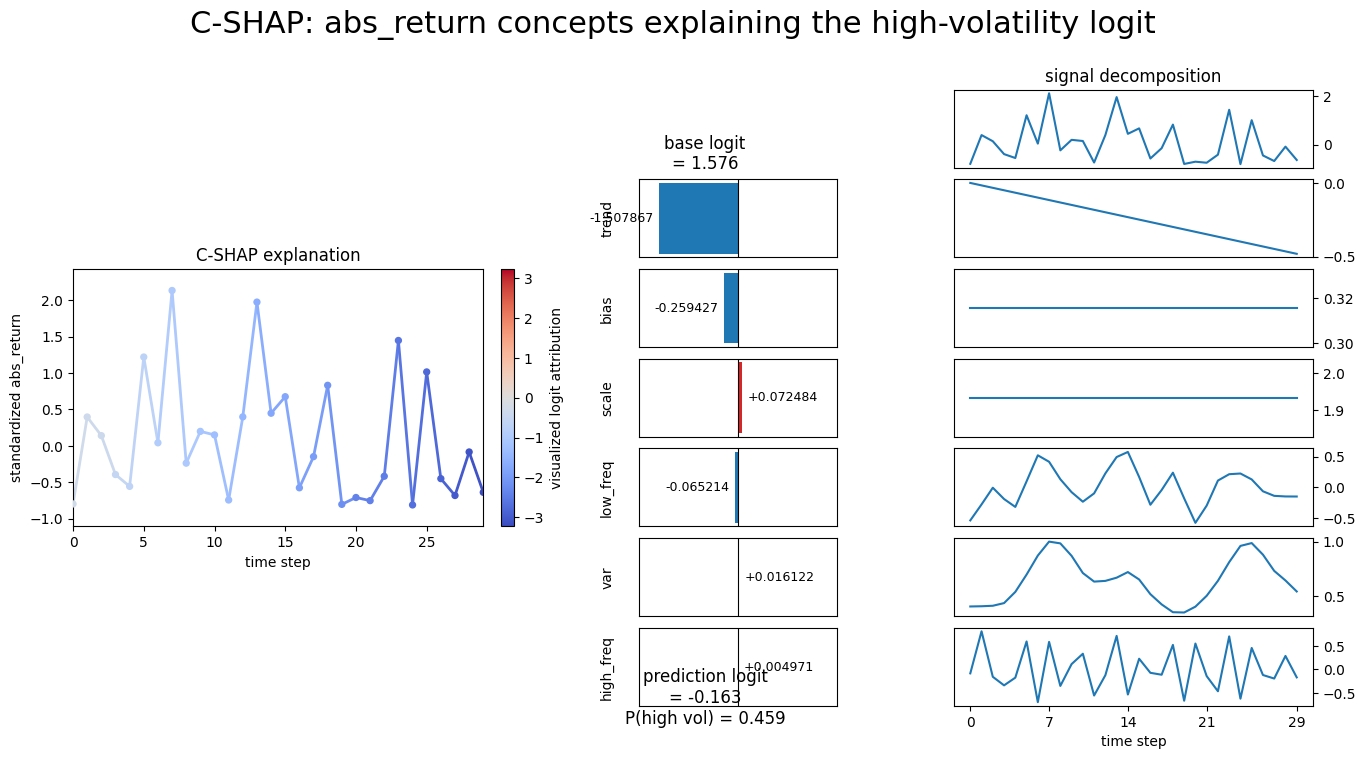

In [18]:
pred_logits = []
pred_probs = []

for i in range(len(x_cshap)):
    x_tensor = torch.tensor(x_cshap[i:i + 1], dtype=torch.float32, device=device)
    with torch.no_grad():
        logit = cshap_logit_model(x_tensor).cpu().item()
        prob = torch.sigmoid(torch.tensor(logit)).item()

    pred_logits.append(logit)
    pred_probs.append(prob)

pred_logits = np.array(pred_logits)
pred_probs = np.array(pred_probs)

base_array = np.asarray(cshap_base_values).squeeze()
if base_array.ndim == 0:
    differences = np.abs(pred_logits - float(base_array))
else:
    differences = np.abs(pred_logits - base_array)

instance_id = int(np.argmax(differences))

base_logit = float(base_array if base_array.ndim == 0 else base_array[instance_id])
prediction_logit = float(pred_logits[instance_id])
prediction_prob = float(pred_probs[instance_id])

plot_cshap_instance(
    signal=x_cshap[instance_id, :, 0],
    decomposition=decomposition,
    shap_values=cshap_values[instance_id].squeeze(),
    base_logit=base_logit,
    prediction_logit=prediction_logit,
    prediction_prob=prediction_prob,
    t=t_cshap,
    title="C-SHAP: abs_return concepts explaining the high-volatility logit",
    path=output_dir / "AbsReturn_LSTM_CSHAP_logit_instance.png",
)

## 12. TP, FP, TN, and FN C-SHAP cases

In [19]:
def prediction_table(model: nn.Module, dataset: Dataset, threshold: float) -> pd.DataFrame:
    rows = []

    model.eval()
    for idx in range(len(dataset)):
        x, y = dataset[idx]
        x = x.unsqueeze(0).to(device)

        with torch.no_grad():
            prob = torch.sigmoid(model(x)).cpu().item()

        rows.append({
            "idx": idx,
            "y_true": int(y.item()),
            "prob": prob,
            "y_pred": int(prob >= threshold),
            "confidence": abs(prob - 0.5),
        })

    return pd.DataFrame(rows)


def select_cases(preds: pd.DataFrame):
    conditions = {
        "TP": (preds["y_true"] == 1) & (preds["y_pred"] == 1),
        "FP": (preds["y_true"] == 0) & (preds["y_pred"] == 1),
        "TN": (preds["y_true"] == 0) & (preds["y_pred"] == 0),
        "FN": (preds["y_true"] == 1) & (preds["y_pred"] == 0),
    }

    selected = {}
    for name, condition in conditions.items():
        subset = preds[condition]
        if subset.empty:
            selected[name] = None
        else:
            selected[name] = subset.sort_values("confidence", ascending=False).iloc[0]

    return selected


preds_uni = prediction_table(cshap_lstm, test_ds_uni, threshold_cshap)
selected_cases = select_cases(preds_uni)

for name, row in selected_cases.items():
    if row is None:
        print(f"{name}: no case found")
    else:
        print(f"{name}: idx={int(row['idx'])}, true={int(row['y_true'])}, pred={int(row['y_pred'])}, prob={row['prob']:.3f}")

TP: idx=673, true=1, pred=1, prob=0.980
FP: idx=682, true=0, pred=1, prob=0.962
TN: idx=749, true=0, pred=0, prob=0.175
FN: idx=748, true=1, pred=0, prob=0.173


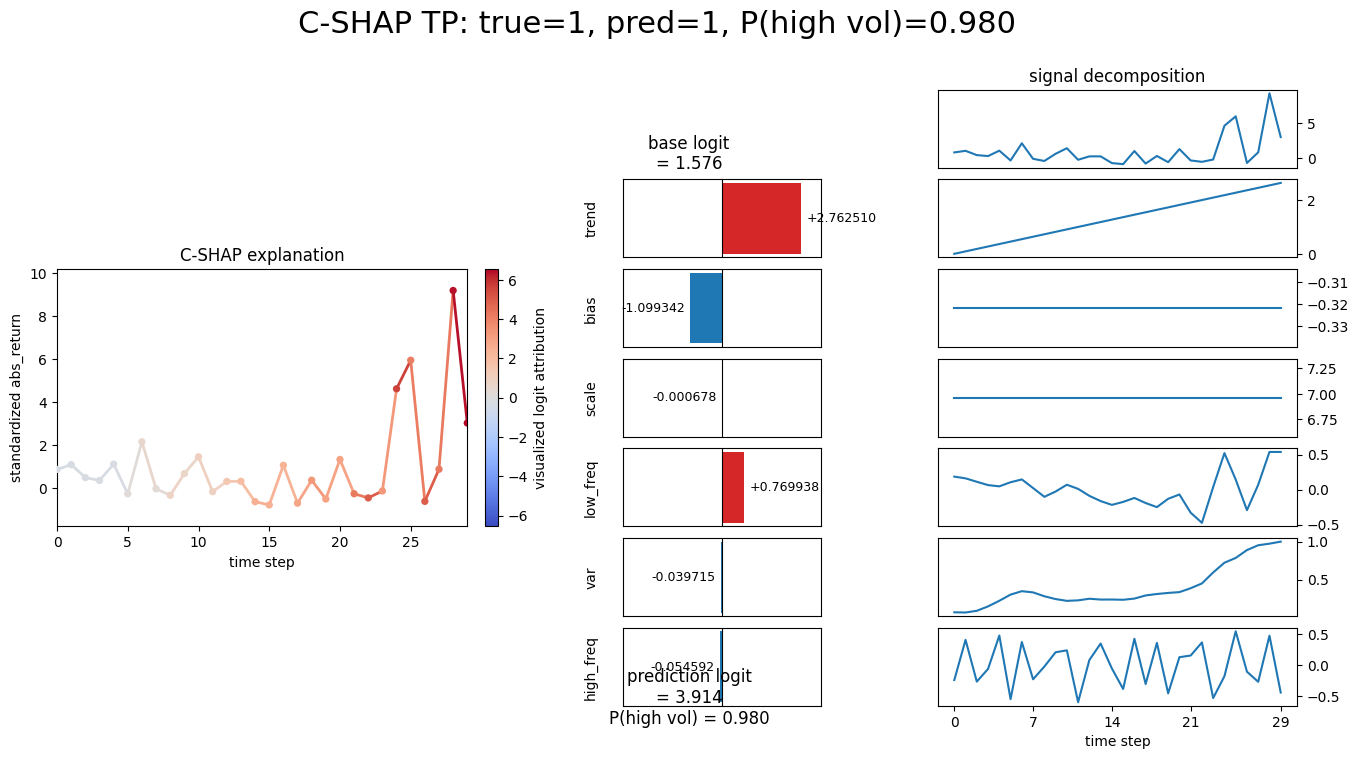

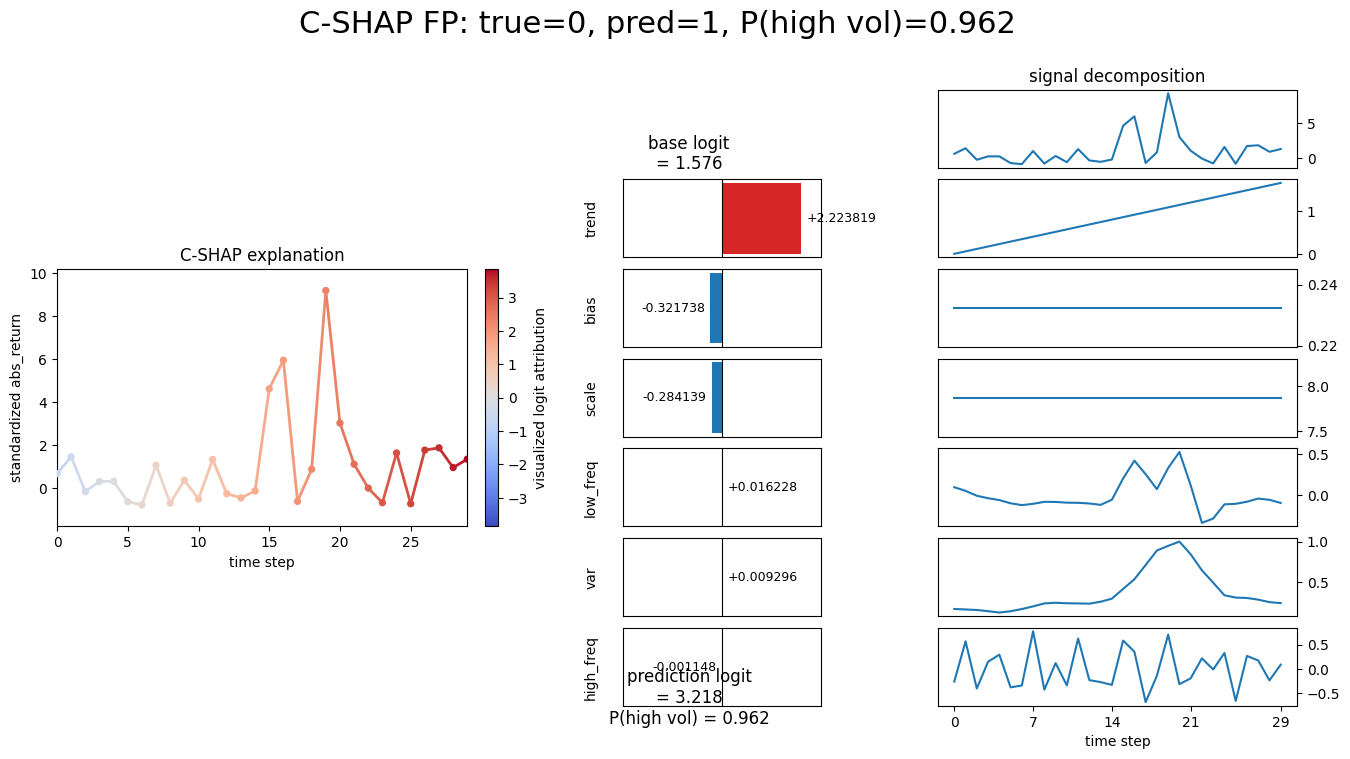

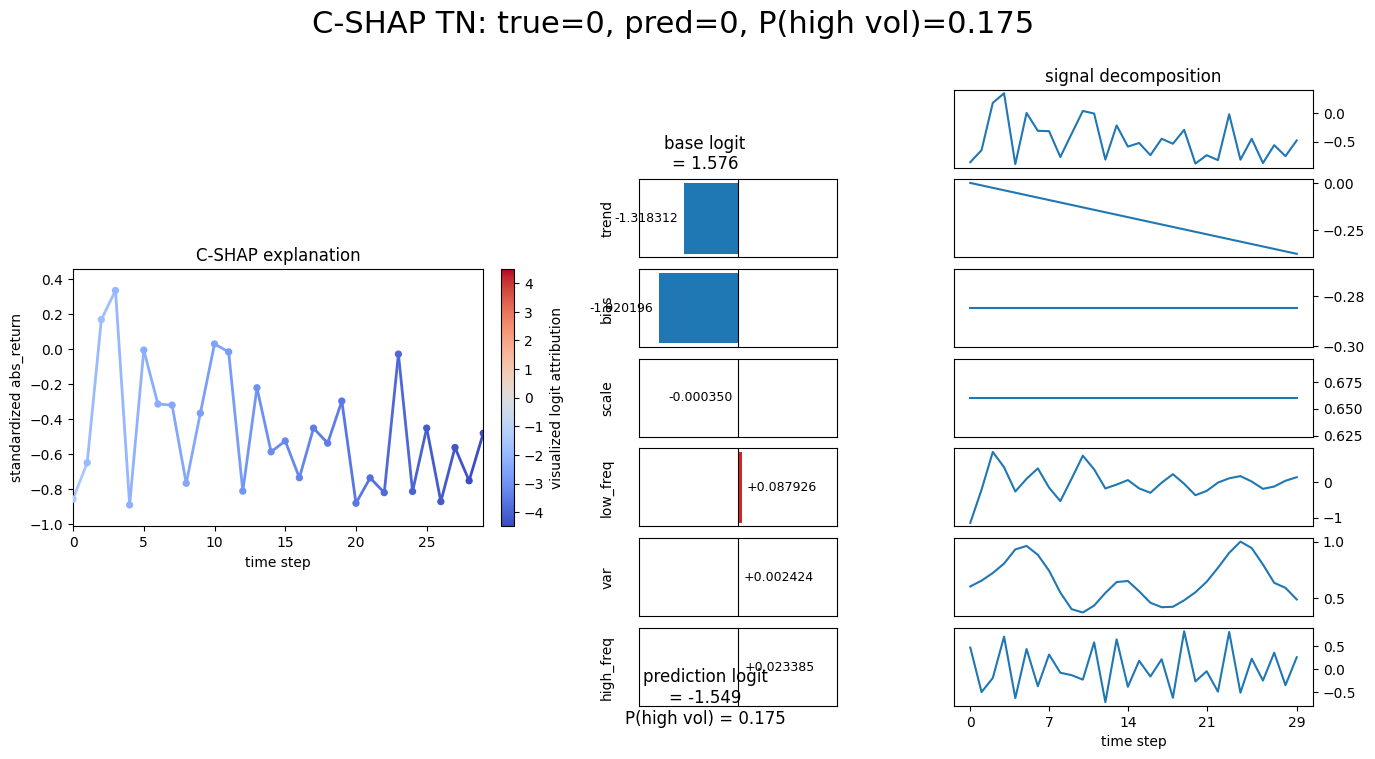

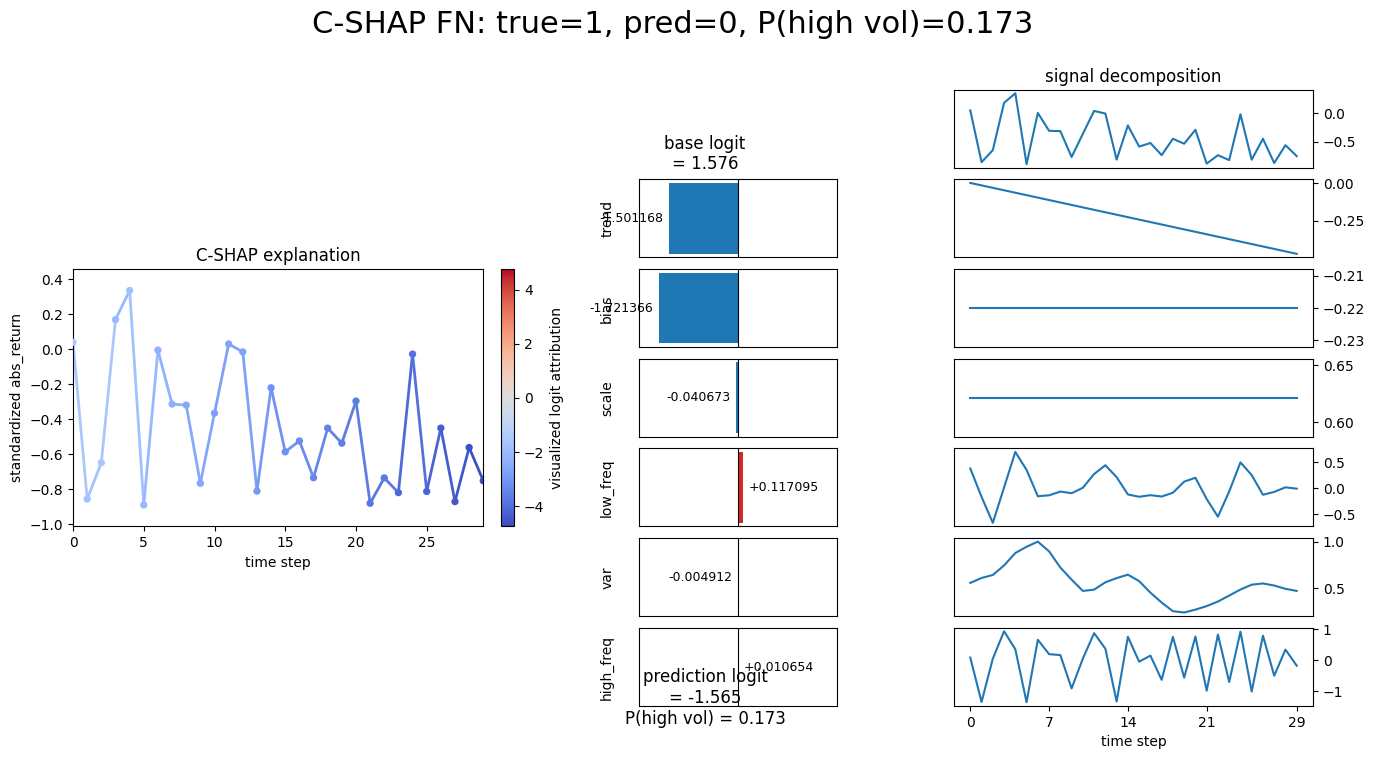

,case,idx,y_true,y_pred,prob,logit,base_logit,cshap_logit_trend,cshap_logit_bias,cshap_logit_scale,cshap_logit_low_freq,cshap_logit_var,cshap_logit_high_freq
0,TP,673,1,1,0.980427,3.913853,1.575732,2.762510,-1.099342,-0.000678,0.769938,-0.039715,-0.054592
1,FP,682,0,1,0.961508,3.218050,1.575732,2.223819,-0.321738,-0.284139,0.016228,0.009296,-0.001148
2,TN,749,0,0,0.175174,-1.549392,1.575732,-1.318312,-1.920196,-0.000350,0.087926,0.002424,0.023385
3,FN,748,1,0,0.172982,-1.564639,1.575732,-1.501168,-1.721366,-0.040673,0.117095,-0.004912,0.010654


In [20]:
case_samples = []
case_meta = []

for case_name, row in selected_cases.items():
    if row is None:
        continue

    x, _ = test_ds_uni[int(row["idx"])]
    case_samples.append(x.numpy())
    case_meta.append({
        "case": case_name,
        "idx": int(row["idx"]),
        "y_true": int(row["y_true"]),
        "y_pred": int(row["y_pred"]),
        "prob": float(row["prob"]),
    })

x_cases = np.stack(case_samples)

case_cshap = CSHAP(
    t=t_cshap,
    background_data=background_uni,
    decomposition=decomposition,
    softmax=False,
)

case_shap_values, case_base_values = case_cshap.shap_values(
    t=t_cshap,
    x_samples=x_cases,
    model=cshap_logit_model,
    device=device,
    exact=cfg.cshap_exact,
)

rows = []

for i, meta in enumerate(case_meta):
    base_vals = np.asarray(case_base_values).squeeze()
    base_logit = float(base_vals if base_vals.ndim == 0 else base_vals[i])
    shap_vals = case_shap_values[i].squeeze()

    x_tensor = torch.tensor(x_cases[i:i + 1], dtype=torch.float32, device=device)
    with torch.no_grad():
        pred_logit = cshap_logit_model(x_tensor).cpu().item()
        pred_prob = torch.sigmoid(torch.tensor(pred_logit)).item()

    row = {
        "case": meta["case"],
        "idx": meta["idx"],
        "y_true": meta["y_true"],
        "y_pred": meta["y_pred"],
        "prob": pred_prob,
        "logit": pred_logit,
        "base_logit": base_logit,
    }

    for component, value in zip(decomposition.component_names, shap_vals):
        row[f"cshap_logit_{component}"] = value

    rows.append(row)

    title = (
        f"C-SHAP {meta['case']}: "
        f"true={meta['y_true']}, pred={meta['y_pred']}, P(high vol)={pred_prob:.3f}"
    )

    plot_cshap_instance(
        signal=x_cases[i, :, 0],
        decomposition=decomposition,
        shap_values=shap_vals,
        base_logit=base_logit,
        prediction_logit=pred_logit,
        prediction_prob=pred_prob,
        t=t_cshap,
        title=title,
        path=output_dir / f"AbsReturn_LSTM_CSHAP_logit_{meta['case']}.png",
    )

case_summary = pd.DataFrame(rows)
case_summary.to_csv(output_dir / "AbsReturn_LSTM_CSHAP_logit_TP_FP_TN_FN.csv", index=False)
case_summary

## 13. Output files

In [21]:
sorted(output_dir.glob("*"))

[WindowsPath('outputs/AbsReturn_LSTM_CSHAP_logit_FN.png'),
 WindowsPath('outputs/AbsReturn_LSTM_CSHAP_logit_FP.png'),
 WindowsPath('outputs/AbsReturn_LSTM_CSHAP_logit_instance.png'),
 WindowsPath('outputs/AbsReturn_LSTM_CSHAP_logit_TN.png'),
 WindowsPath('outputs/AbsReturn_LSTM_CSHAP_logit_TP.png'),
 WindowsPath('outputs/AbsReturn_LSTM_CSHAP_logit_TP_FP_TN_FN.csv'),
 WindowsPath('outputs/AbsReturn_LSTM_global_cshap_logit_importance.png'),
 WindowsPath('outputs/AbsReturn_LSTM_official_cshap_logit_summary.csv'),
 WindowsPath('outputs/AbsReturn_LSTM_probability_histogram.png'),
 WindowsPath('outputs/AbsReturn_LSTM_probability_series.png'),
 WindowsPath('outputs/CNN_concept_shap.csv'),
 WindowsPath('outputs/CNN_concept_shap.png'),
 WindowsPath('outputs/CNN_integrated_gradients.csv'),
 WindowsPath('outputs/CNN_integrated_gradients.png'),
 WindowsPath('outputs/CNN_predictions.png'),
 WindowsPath('outputs/CNN_probability_histogram.png'),
 WindowsPath('outputs/CNN_probability_series.png'),
 Wi

## Notes for the report

The forecasting target is a high-volatility regime indicator based on future five-day realized volatility. The threshold is estimated from the training period only.

The multivariate models are explained with concept-level Shapley attribution, WindowSHAP, and Integrated Gradients. The official decomposition-based C-SHAP method is applied to a univariate LSTM trained on the absolute-return channel, because absolute returns are directly related to realized volatility and contain visible volatility spikes.

C-SHAP is applied to the model logit instead of the sigmoid probability. Positive C-SHAP values increase the model's evidence for a high-volatility regime, while negative values decrease that evidence. This avoids probability compression and usually produces clearer component-level attributions.

The global C-SHAP summary reports mean absolute component importance across explained test samples. The TP/FP/TN/FN cases are included to compare explanations for correct and incorrect predictions.
